<a href="https://colab.research.google.com/github/anabeathrizrt/alura-analise-dados/blob/main/Projeto_Curso_Estatistica_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# <font color=green size=10>CURSO DE ESTATÍSTICA - PARTE 1</font>
***

## Trabalho de Análise Descritiva de um Conjunto de Dados

Utilizando os conhecimentos adquiridos em nosso treinamento realize uma análise descritiva básica de um conjunto de dados retirados da Pesquisa Nacional por Amostra de Domicílios - 2015 do IBGE.

Vamos construir histogramas, calcular e avaliar medidas de tendência central, medidas separatrizes e de dispersão dos dados.

Siga o roteiro proposto e vá completando as células vazias. Procure pensar em mais informações interessantes que podem ser exploradas em nosso dataset.

# <font color=green>DATASET DO PROJETO</font>
***

### Pesquisa Nacional por Amostra de Domicílios - 2015

A <b>Pesquisa Nacional por Amostra de Domicílios - PNAD</b> investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas. O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### Fonte dos Dados

https://ww2.ibge.gov.br/home/estatistica/populacao/trabalhoerendimento/pnad2015/microdados.shtm

### Variáveis utilizadas

> ### Renda
> ***

Rendimento mensal do trabalho principal para pessoas de 10 anos ou mais de idade.

> ### Idade
> ***

Idade do morador na data de referência em anos.

> ### Altura (elaboração própria)
> ***

Altura do morador em metros.

> ### UF
> ***

|Código|Descrição|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Anos de Estudo
> ***

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados|
||Não aplicável|

> ### Cor
> ***

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|
|9|Sem declaração|

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a <b>Renda</b> era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a <b>Renda</b> era missing;
> 3. Foram considerados somente os registros das <b>Pessoas de Referência</b> de cada domicílio (responsável pelo domicílio).

***
***

### Utilize a célula abaixo para importar as biblioteca que precisar para executar as tarefas
#### <font color='red'>Sugestões: pandas, numpy, seaborn</font>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

### Importe o dataset e armazene o conteúdo em uma DataFrame

In [ ]:
dados = pd.read_csv('dados.csv')

### Visualize o conteúdo do DataFrame

In [ ]:
dados.head()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


### Para avaliarmos o comportamento da variável RENDA vamos construir uma tabela de frequências considerando as seguintes classes em salários mínimos (SM)
#### <font color='blue'>Descreva os pontos mais relevantes que você observa na tabela e no gráfico.</font>

Classes de renda:

<b>A</b> ► Acima de 25 SM

<b>B</b> ► De 15 a 25 SM

<b>C</b> ► De 5 a 15 SM

<b>D</b> ► De 2 a 5 SM

<b>E</b> ► Até 2 SM

Para construir as classes de renda considere que o salário mínimo na época da pesquisa era de <b>R$ 788,00</b>.

#### Siga os passos abaixo:

### 1º Definir os intevalos das classes em reais (R$)

In [ ]:
classes = [dados.Renda.min(), 2*788, 5*788, 15*788, 25*788, dados.Renda.max()]
print(classes)

[0, 1576, 3940, 11820, 19700, 200000]


### 2º Definir os labels das classes

In [ ]:
labels = ['E', 'D', 'C', 'B', 'A']

### 3º Construir a coluna de frequências

In [ ]:
frequencia = pd.cut(x=dados.Renda,
                     bins=classes,
                     labels=labels,
                     include_lowest=True).value_counts()
frequencia

,count
Renda,
E,49755
D,18602
C,7241
B,822
A,420


### 4º Construir a coluna de percentuais

In [ ]:
percentual = pd.cut(x=dados.Renda,
                     bins=classes,
                     labels=labels,
                     include_lowest=True).value_counts(normalize=True) * 100
percentual

,proportion
Renda,
E,64.751432
D,24.208745
C,9.423477
B,1.069755
A,0.546590


### 5º Juntar as colunas de frequência e percentuais e ordenar as linhas de acordo com os labels das classes

In [ ]:
juntos = pd.DataFrame(
    {'Frequência' : frequencia, 'Porcentagem (%)' : percentual}
    )
juntos

,Frequência,Porcentagem (%)
Renda,,
E,49755,64.751432
D,18602,24.208745
C,7241,9.423477
B,822,1.069755
A,420,0.546590


### Construa um gráfico de barras para visualizar as informações da tabela de frequências acima

<Axes: xlabel='Renda'>

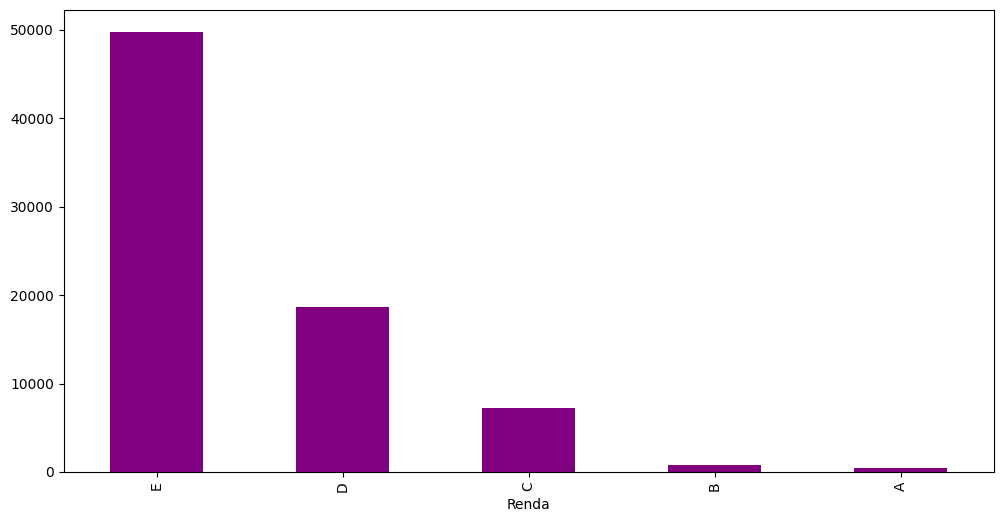

In [ ]:
juntos['Frequência'].plot.bar(width = 0.5, color = 'purple', figsize = (12, 6)  )

> ### Conclusões

  Observando o gráfico, é possível notar que a maioria dos usuários (64,76%) está concentrada na Classe E, ou seja, ganha até 2 salários mínimos. Essa concentração já demonstra uma distribuição de renda bastante desigual, com a maior parte dos usuários situada nas faixas mais baixas de renda. Esse padrão fica ainda mais evidente ao observar o outro extremo do gráfico: as classes A e B (acima de 15 SM) juntas representam apenas 1,61% da amostra, evidenciando que rendas altas são exceção entre os usuários. Além disso, a queda entre as barras não é gradual, mas sim brusca logo entre as classes E e D, o que reforça o caráter concentrado (e não distribuído de forma equilibrada) da renda nesse grupo.

### Crie um histograma para as variáveis QUANTITATIVAS de nosso dataset
#### <font color='blue'>Descreva os pontos mais relevantes que você observa nos gráficos (assimetrias e seus tipos, possíveis causas para determinados comportamentos etc.)</font>

/tmp/ipykernel_1521/427168401.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dados.Renda)


<Axes: title={'center': 'Variáveis Quantitativas - Renda '}, xlabel='Renda', ylabel='Usuários'>

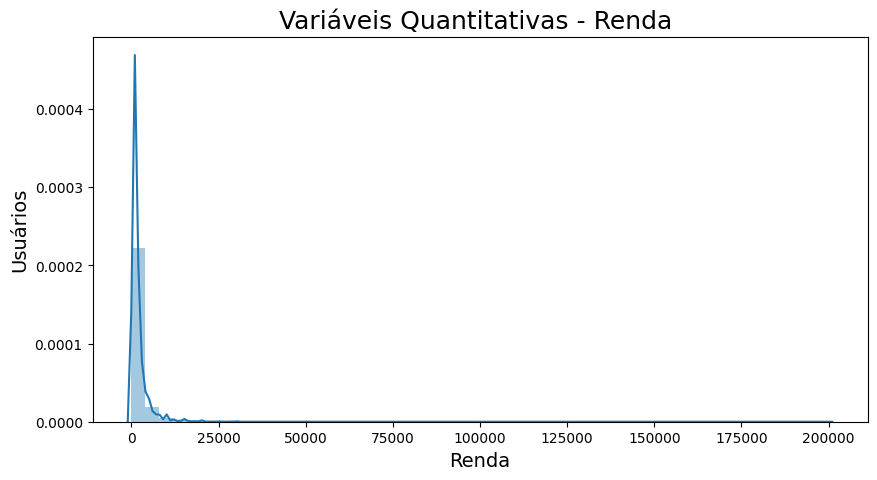

In [ ]:
ax = sns.distplot(dados.Renda)
ax.figure.set_size_inches(10, 5)
ax.set_title('Variáveis Quantitativas - Renda ', fontsize = 18)
ax.set_xlabel('Renda', fontsize = 14)
ax.set_ylabel('Usuários', fontsize = 14)
ax

<Axes: title={'center': 'Variáveis Quantitativas - Altura '}, xlabel='Metros', ylabel='Count'>

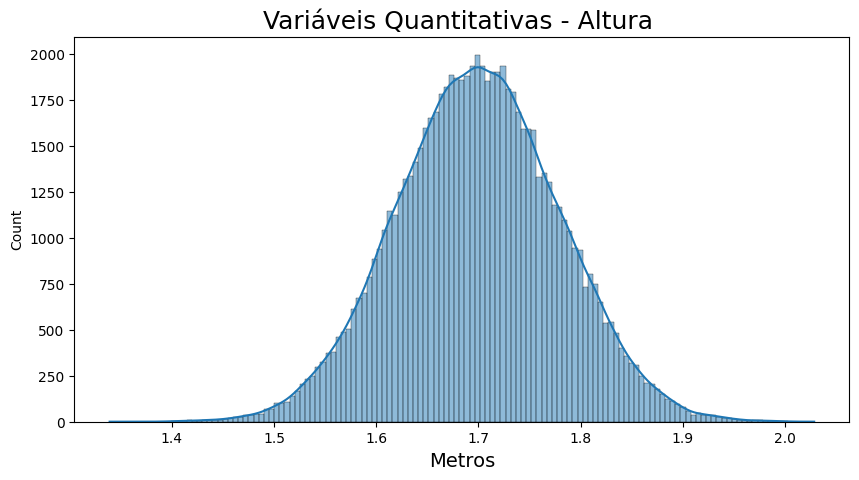

In [ ]:
ax = sns.histplot(dados.Altura, kde = True)
ax.figure.set_size_inches(10, 5)
ax.set_title('Variáveis Quantitativas - Altura ', fontsize = 18)
ax.set_xlabel('Metros', fontsize = 14)
ax

<Axes: title={'center': 'Variáveis Quantitativas - Idade '}, xlabel='Anos', ylabel='Count'>

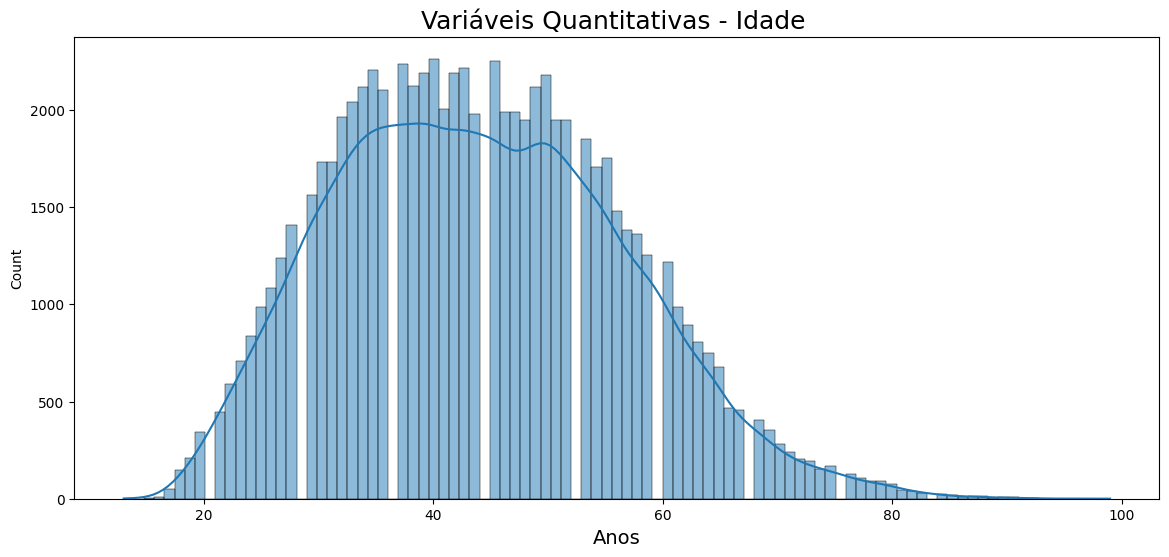

In [ ]:
ax = sns.histplot(dados.Idade, kde = True)
ax.figure.set_size_inches(14, 6)
ax.set_title('Variáveis Quantitativas - Idade ', fontsize = 18)
ax.set_xlabel('Anos', fontsize = 14)
ax

> ### Conclusões

Observando os três histogramas, é possível identificar comportamentos distintos entre as variáveis. As variáveis **Altura** e **Idade** apresentam distribuições aproximadamente simétricas. Isso ocorre porque os valores dessas variáveis estão bem distribuídos ao redor de um valor central, sem grandes concentrações em um extremo, formando um padrão equilibrado dos dois lados.

Já a variável **Renda** apresenta uma distribuição assimétrica à direita. Isso se justifica pelo fato de que a maior parte dos usuários está concentrada nas classes de renda mais baixas, enquanto uma pequena fração da amostra possui rendas muito altas, formando uma longa cauda que se estende para a direita do gráfico.


### Para a variável RENDA, construa um histograma somente com as informações das pessoas com rendimento até R$ 20.000,00

/tmp/ipykernel_1521/1400025558.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dados.query('Renda < 20000').Renda, kde=True)


<Axes: title={'center': 'Variáveis Quantitativas - Renda até R$ 2.000'}, xlabel='Renda', ylabel='Usuários'>

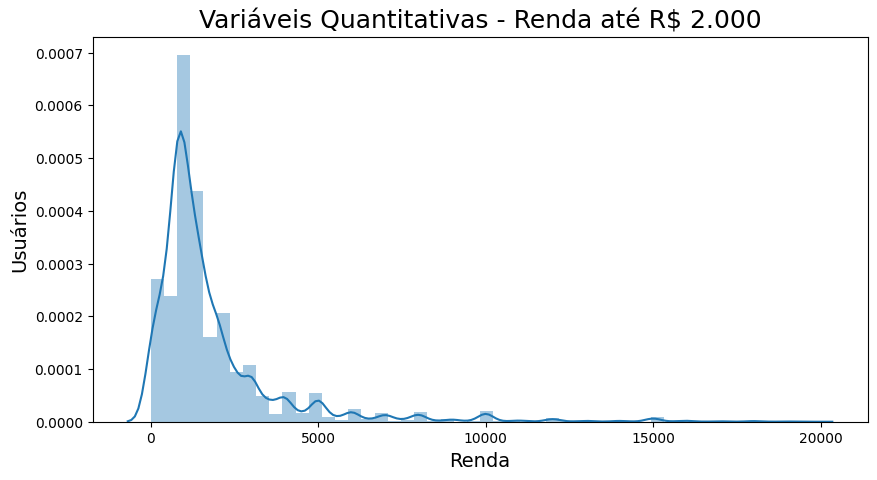

In [ ]:
ax = sns.distplot(dados.query('Renda < 20000').Renda, kde=True)
ax.figure.set_size_inches(10, 5)
ax.set_title('Variáveis Quantitativas - Renda até R$ 2.000', fontsize = 18)
ax.set_xlabel('Renda', fontsize = 14)
ax.set_ylabel('Usuários', fontsize = 14)
ax

### Construa uma tabela de frequências e uma com os percentuais do cruzando das variáveis SEXO e COR
#### <font color='blue'>Avalie o resultado da tabela e escreva suas principais conclusões</font>
#### <font color='red'>Utilize os dicionários abaixo para renomear as linha e colunas das tabelas de frequências e dos gráficos em nosso projeto</font>

In [ ]:
sexo = {
    0: 'Masculino',
    1: 'Feminino'
}
cor = {
    0: 'Indígena',
    2: 'Branca',
    4: 'Preta',
    6: 'Amarela',
    8: 'Parda',
    9: 'Sem declaração'
}
anos_de_estudo = {
    1: 'Sem instrução e menos de 1 ano',
    2: '1 ano',
    3: '2 anos',
    4: '3 anos',
    5: '4 anos',
    6: '5 anos',
    7: '6 anos',
    8: '7 anos',
    9: '8 anos',
    10: '9 anos',
    11: '10 anos',
    12: '11 anos',
    13: '12 anos',
    14: '13 anos',
    15: '14 anos',
    16: '15 anos ou mais',
    17: 'Não determinados'
}
uf = {
    11: 'Rondônia',
    12: 'Acre',
    13: 'Amazonas',
    14: 'Roraima',
    15: 'Pará',
    16: 'Amapá',
    17: 'Tocantins',
    21: 'Maranhão',
    22: 'Piauí',
    23: 'Ceará',
    24: 'Rio Grande do Norte',
    25: 'Paraíba',
    26: 'Pernambuco',
    27: 'Alagoas',
    28: 'Sergipe',
    29: 'Bahia',
    31: 'Minas Gerais',
    32: 'Espírito Santo',
    33: 'Rio de Janeiro',
    35: 'São Paulo',
    41: 'Paraná',
    42: 'Santa Catarina',
    43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul',
    51: 'Mato Grosso',
    52: 'Goiás',
    53: 'Distrito Federal'
}

In [ ]:
freq_sexo_cor = pd.crosstab(dados.Sexo,dados.Cor)
freq_sexo_cor.rename(index = sexo, inplace = True)
freq_sexo_cor.rename(columns = cor, inplace = True)
freq_sexo_cor

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,256,22194,5502,235,25063
Feminino,101,9621,2889,117,10862


In [ ]:
percentual_sexo_cor = pd.crosstab(dados.Sexo, dados.Cor, normalize = True) * 100
percentual_sexo_cor.rename(index = sexo, inplace = True)
percentual_sexo_cor.rename(columns = cor, inplace = True)
percentual_sexo_cor

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,0.333160,28.883394,7.160333,0.305830,32.617126
Feminino,0.131442,12.520822,3.759761,0.152264,14.135867


> ### Conclusões

Analisando a tabela de percentuais, os valores que mais se destacam são os de homens pardos (32,62%) e homens brancos (28,88%), que juntos representam mais de 60% do total da amostra. Em contraste, homens de outras cores (indígena, preta e amarela) somam apenas cerca de 7,80%.

Ao observar a tabela de frequências absolutas, um ponto interessante aparece: entre as cores menos representadas, a população preta (5.502 homens) é numericamente maior que a indígena e a amarela somadas, mesmo que, percentualmente, ainda seja pequena diante da soma de brancos e pardos (22.194 + 25.063 = 47.257).

Em relação às mulheres, o padrão se repete: a maioria também é parda (14,14%), seguida de perto pelas brancas (12,52%). As demais cores (preta, amarela e indígena) juntas não chegam a 5% do total feminino (4,04%).
De forma geral, nota-se que a distribuição por cor segue um padrão semelhante entre homens e mulheres: concentração nas categorias parda e branca, com baixa representatividade das demais. Entretanto a proporção de homens na amostra é consideravelmente maior que a de mulheres em todas as categorias de cor.


## Realize, para a variável RENDA, uma análise descritiva com as ferramentas que aprendemos em nosso treinamento

### Obtenha a média aritimética

In [ ]:
float(dados.Renda.mean())

2000.3831988547631

### Obtenha a mediana

In [ ]:
float(dados.Renda.median())

1200.0

### Obtenha a moda

In [ ]:
int(dados.Renda.mode())

/tmp/ipykernel_1521/2695851643.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  int(dados.Renda.mode())


788

### Obtenha o desvio médio absoluto

In [ ]:
dv = (dados.Renda - dados.Renda.mean()).abs().mean()
dv

np.float64(1526.4951371638058)

### Obtenha a variância

In [ ]:
dados.Renda.var()

11044906.00622118

### Obtenha o desvio-padrão

In [ ]:
dados.Renda.std()

3323.3877303470294

### Obtenha a média, mediana e valor máximo da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mean', 'median', 'max'}</i></font>

In [ ]:
estatisticas_renda = pd.crosstab(dados.Sexo,
                         dados.Cor,
                         aggfunc = ['mean','median','max'],
                         values = dados.Renda)
estatisticas_renda.rename(index = sexo, inplace = True)
estatisticas_renda.rename(columns = cor, inplace = True)
estatisticas_renda

mean                                                      \
Cor           Indígena       Branca        Preta      Amarela        Parda   
Sexo                                                                         
Masculino  1081.710938  2925.744435  1603.861687  4758.251064  1659.577425   
Feminino   2464.386139  2109.866750  1134.596400  3027.341880  1176.758516   

            median                                      max                 \
Cor       Indígena  Branca   Preta Amarela   Parda Indígena  Branca  Preta   
Sexo                                                                         
Masculino    797.5  1700.0  1200.0  2800.0  1200.0    10000  200000  50000   
Feminino     788.0  1200.0   800.0  1500.0   800.0   120000  100000  23000   

                           
Cor       Amarela   Parda  
Sexo                       
Masculino   50000  100000  
Feminino    20000   30000

> ### Conclusões

Homens e mulheres pretos e pardos são os que recebem menos em média (exceto pelos homens indígenas) , enquanto os amarelos de ambos os gêneros são os que recebem mais tanto na média quanto na mediana.

Mulheres indígenas têm, em média, renda maior que homens indígenas (2.464,39 vs. 1.081,71), provavelmente porque o valor máximo desse grupo (120.000) é muito superior aos demais, distorcendo a média para cima. No entanto, ao olhar a mediana, os homens indígenas têm uma renda pouco superior (797,50 vs. 788,00), uma diferença de apenas 1,21%. É também a menor diferença entre medianas observada em toda a tabela, o que sugere que, para o usuário "típico" desses dois grupos, a renda é praticamente equivalente.

Em relação aos valores máximos, Homens Brancos apresentam o maior valor da tabela (200.000), seguidos por Homens Pardos (100.000),  ambos casos isolados que também distorcem as respectivas médias desses grupos para cima, sem representar a renda típica da maioria.


### Obtenha as medidas de dispersão da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mad', 'var', 'std'}</i></font>

In [ ]:
estatisticas_renda = pd.crosstab(dados.Sexo,
                         dados.Cor,
                         aggfunc = [lambda x: (x - x.mean()).abs().mean(),'var','std'],
                         values = dados.Renda)
estatisticas_renda.rename(index = sexo, inplace = True)
estatisticas_renda.rename(columns = cor, inplace = True)
estatisticas_renda

<lambda>                                                     \
Cor           Indígena       Branca       Preta      Amarela        Parda   
Sexo                                                                        
Masculino   798.910889  2261.012346  975.602482  3709.597211  1125.827704   
Feminino   3007.892952  1670.967106  705.453357  2549.146322   811.580946   

                    var                                            \
Cor            Indígena        Branca         Preta       Amarela   
Sexo                                                                
Masculino  1.449841e+06  2.257002e+07  3.749294e+06  3.295707e+07   
Feminino   1.429818e+08  1.056909e+07  1.821960e+06  1.392166e+07   

                                  std                                        \
Cor               Parda      Indígena       Branca        Preta     Amarela   
Sexo                                                                          
Masculino  5.345747e+06   1204.093490  4750.791872  1936.309271  5740.82482   
Feminino   2.547960e+06  11957.498292  3251.013154  1349.799809  3731.17366   

                        
Cor              Parda  
Sexo                    
Masculino  2312.087184  
Feminino   1596.233048

> ### Conclusões

Mulheres indígenas têm a maior discrepância entre o desvio médio e o desvio-padrão de toda a tabela, enquanto homens indígenas apresentam uma discrepância bem menor entre essas duas medidas. Isso pode ser explicado pelo mesmo ponto observado na questão anterior: o valor máximo de renda desse grupo (R$ 120.000) é um outlier, que infla o desvio-padrão, já que essa medida é mais sensível a valores extremos do que o desvio médio.

Os grupos de cor amarela também apresentam elevada dispersão: homens e mulheres amarelos possuem os maiores valores de desvio médio e desvio-padrão entre todas as cores, padrão coerente com o fato de também apresentarem as maiores rendas médias.

Já entre os homens, os grupos pretos e pardos apresentam as menores medidas de dispersão, indicando menor variabilidade das rendas. Esse resultado também é coerente com o fato de esses grupos apresentarem menores rendas médias.

### Construa um box plot da variável RENDA segundo SEXO e COR
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

Text(0.5, 0, '$')

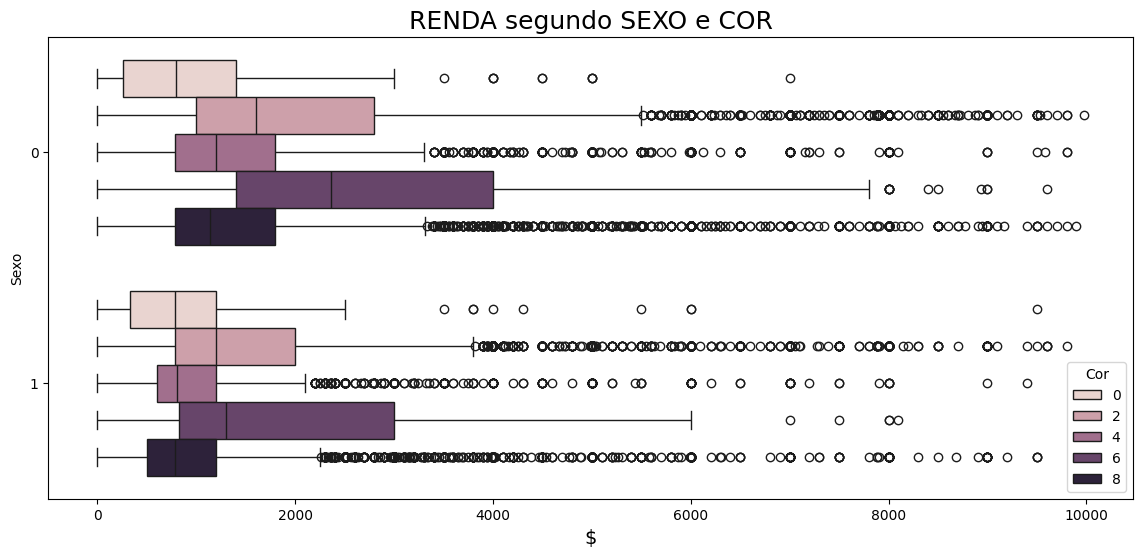

In [ ]:
cor = {
    0: 'Indígena',
    2: 'Branca',
    4: 'Preta',
    6: 'Amarela',
    8: 'Parda',
    9: 'Sem declaração'
}

ax = sns.boxplot(x = 'Renda', y = 'Sexo', hue = 'Cor', data = dados.query('Renda < 10000'), orient='h')
ax.figure.set_size_inches(14, 6)
ax.set_title(' RENDA segundo SEXO e COR ', fontsize=18)
ax.set_xlabel('$', fontsize=14)

> ### Conclusões

Observa-se que as distribuições de renda apresentam, em geral, assimetria à direita, devido à presença de indivíduos com rendas muito superiores à maior parte da população. O grupo indígena apresenta a distribuição mais próxima da simétrica, enquanto os grupos branco e amarelo exibem maior assimetria à direita.

Os indivíduos de cor amarela apresentam maior dispersão da renda, evidenciada tanto pela maior amplitude da caixa quanto pelos bigodes mais extensos, resultado coerente com os maiores valores de desvio observados anteriormente. Em contraste, os indígenas apresentam menor variabilidade.

Os grupos pardos concentram a maior quantidade de outliers, indicando a presença de diversos indivíduos com rendas muito acima da distribuição central do grupo. Além disso, observa-se que, para todas as cores, os homens apresentam medianas de renda superiores às das mulheres, sugerindo diferenças de rendimento entre os sexos.

# <font color="red">DESAFIO<font>
### Qual percentual de pessoas de nosso <i>dataset</i> ganham um salário mínimo (R$ 788,00) ou menos?
#### <font color='red'>Utilize a função <i>percentileofscore()</i> do <i>scipy</i> para realizar estas análises.</font>
#### Mais informações: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html


In [ ]:
from scipy import stats

percentual = stats.percentileofscore(dados['Renda'], 788, kind='weak')
print(f'{percentual:.2f}% das pessoas ganham R$ 788,00 ou menos.')

28.87% das pessoas ganham R$ 788,00 ou menos.


### Qual o valor máximo ganho por 99% das pessoas de nosso <i>dataset</i>?
#### <font color='red'>Utilize o método <i>quantile()</i> do <i>pandas</i> para realizar estas análises.</font>

In [ ]:
valor = dados.Renda.quantile(.99)
print(f'O valor máximo ganho por 99% das pessoas é R${round(valor)}.')

O valor máximo ganho por 99% das pessoas é R$15000.


### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = ['mean', 'median', 'max', 'std']</i></font>

In [ ]:
estatisticas_anos = pd.crosstab(
    dados['Anos de Estudo'],
    dados['Sexo'],
    values=dados['Renda'],
    aggfunc=['mean', 'median', 'max', 'std'])

estatisticas_anos.rename(index=anos_de_estudo, inplace=True)
estatisticas_anos.rename(columns=sexo, inplace=True)

estatisticas_anos

mean                 median           \
Sexo                              Masculino     Feminino Masculino Feminino   
Anos de Estudo                                                                
Sem instrução e menos de 1 ano   799.494638   516.201748     700.0    390.0   
1 ano                            895.629047   492.771987     788.0    400.0   
2 anos                           931.178986   529.911638     788.0    450.0   
3 anos                          1109.203862   546.853916     800.0    500.0   
4 anos                          1302.329283   704.279111    1000.0    788.0   
5 anos                          1338.653218   781.389776    1045.0    788.0   
6 anos                          1448.875419   833.732824    1200.0    788.0   
7 anos                          1465.497940   830.751004    1200.0    788.0   
8 anos                          1639.396667   933.615351    1300.0    800.0   
9 anos                          1508.038850   868.021700    1200.0    788.0   
10 anos                         1731.270847   925.919225    1218.0    800.0   
11 anos                         2117.060504  1286.790889    1500.0   1000.0   
12 anos                         2470.330776  1682.313725    1800.0   1200.0   
13 anos                         3195.099154  1911.730047    2400.0   1300.0   
14 anos                         3706.620269  2226.460457    2500.0   1600.0   
15 anos ou mais                 6134.279790  3899.513231    4000.0   2800.0   
Não determinados                1295.761905   798.174419    1200.0    788.0   

                                     max                   std               
Sexo                           Masculino Feminino    Masculino     Feminino  
Anos de Estudo                                                               
Sem instrução e menos de 1 ano     30000    10000  1023.904884   639.311534  
1 ano                              30000     2000  1331.950552   425.291842  
2 anos                             40000     4000  1435.173827   498.234168  
3 anos                             80000     3500  2143.800133   424.124446  
4 anos                             50000    10000  1419.821787   629.553397  
5 anos                             35000     8000  1484.650587   635.782641  
6 anos                             25000     6000  1476.628602   574.547028  
7 anos                             40000     9000  1419.708673   602.038029  
8 anos                             30000    18000  1515.583715   896.781213  
9 anos                             60000    20000  2137.664774   973.221652  
10 anos                            45000     6000  2078.609734   620.611907  
11 anos                           200000   100000  2676.538942  1819.040417  
12 anos                            30000   120000  2268.081538  4851.833513  
13 anos                            25000    20000  2797.116800  2053.789771  
14 anos                            50000    20000  3987.214974  2064.083336  
15 anos ou mais                   200000   100000  7447.613594  4212.770709  
Não determinados                    7000     3000   979.648745   459.985964

Observa-se uma relação positiva entre os anos de estudo e a renda. À medida que o nível de escolaridade aumenta, tanto a média quanto a mediana da renda tendem a crescer para homens e mulheres. Os maiores valores são encontrados no grupo com 15 anos ou mais de estudo, cuja média é de aproximadamente R$ 6.134,28 para os homens e 3.899,51 para as mulheres.

Em todos os níveis de escolaridade, os homens apresentam média e mediana de renda superiores às das mulheres, evidenciando uma diferença de rendimento entre os sexos mesmo para indivíduos com o mesmo tempo de estudo.

Os valores máximos de renda também tendem a aumentar com a escolaridade. O maior valor observado foi de 200.000, registrado entre homens com 11 anos de estudo e também entre aqueles com 15 anos ou mais. Entre as mulheres, o maior valor foi de 120.000, observado no grupo com 12 anos de estudo.

O desvio-padrão cresce conforme aumentam os anos de estudo, principalmente entre os homens, indicando maior variabilidade das rendas nos níveis mais elevados de escolaridade. O grupo masculino com 15 anos ou mais de estudo apresenta o maior desvio-padrão 7.447,61, enquanto entre as mulheres esse maior valor ocorre aos 12 anos de escolaridade com 4851. Isso sugere que, embora pessoas com maior escolaridade tenham rendas mais elevadas, também existe uma maior desigualdade de rendimentos dentro desses grupos.

### Construa um box plot da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Utilize a variável IDADE para identificar se a desigualdade se verifica para pessoas de mesma idade. Exemplo: <i>data=dados.query('Renda < 10000 and Idade == 40')</i> ou <i>data=dados.query('Renda < 10000 and Idade == 50')</i></font>
#### <font color='red'>3º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

Text(0.5, 0, '$')

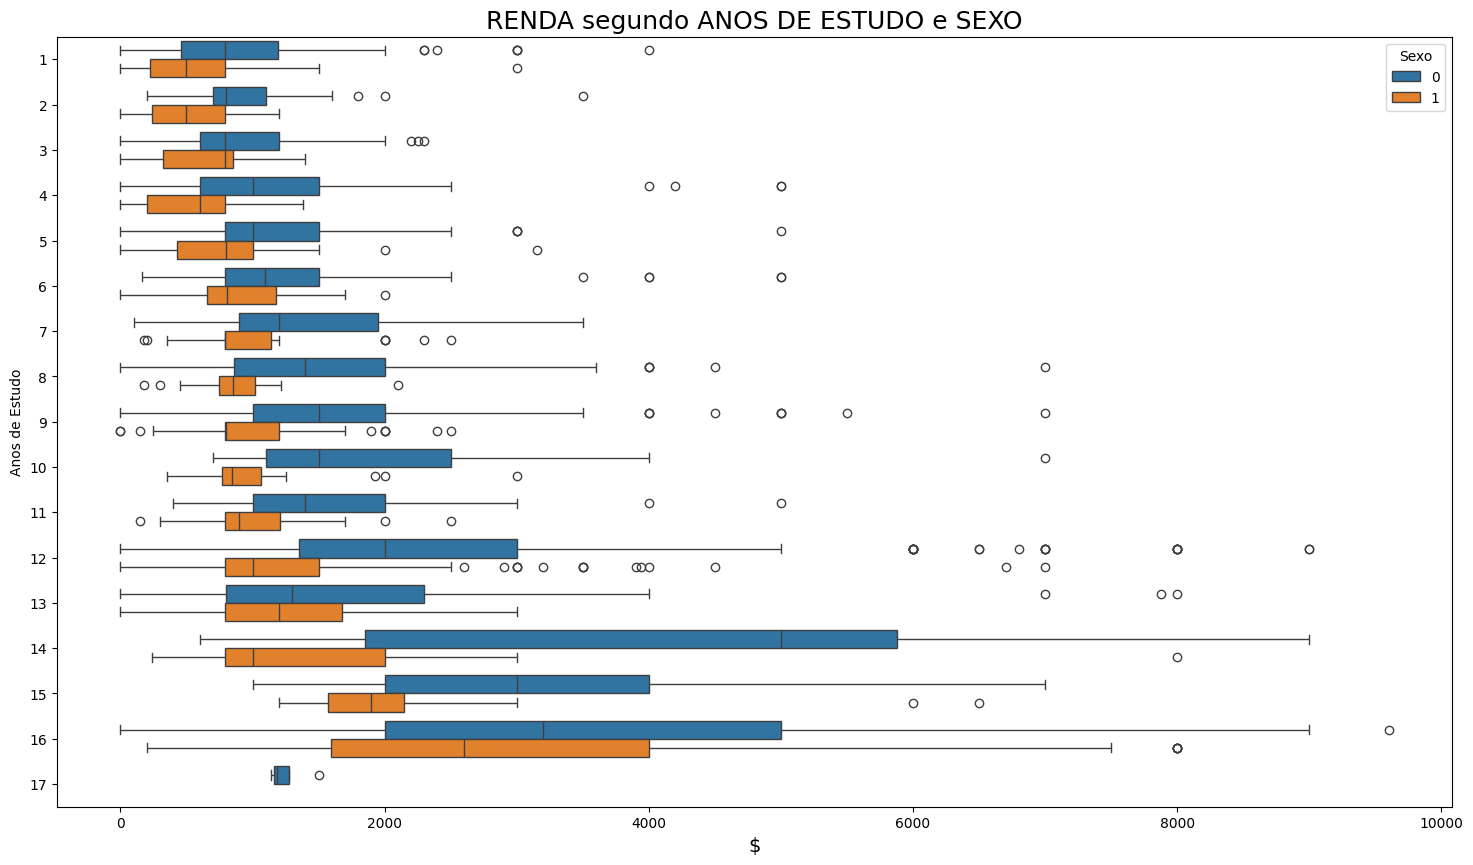

In [ ]:
ax = sns.boxplot(x = 'Renda', y = 'Anos de Estudo', hue = 'Sexo', data=dados.query('Renda < 10000 and Idade == 50'), orient='h')
ax.figure.set_size_inches(18, 10)
ax.set_title('RENDA segundo ANOS DE ESTUDO e SEXO', fontsize=18)
ax.set_xlabel('$', fontsize=14)

> ### Conclusões

O gráfico mostra uma tendência clara de que mais anos de estudo correspondem a maior renda, especialmente a partir de 12+ anos de estudo (ensino médio completo em diante), as caixas ficam maiores e mais deslocadas à direita, com outliers alcançando valores extremos (até R$ 9.600 com 16 anos de estudo). Também fica evidente uma desigualdade de gênero consistente em todos os níveis de escolaridade: a caixa laranja (Sexo Feminino) está sempre à esquerda da azul (Sexo Masculino), indicando que, no mesmo nível educacional, o sexo feminino  ganha sistematicamente menos, essa diferença inclusive se amplia nos anos de estudo mais altos (14 a 16 anos), onde a distância entre as medianas dos dois grupos fica maior. Ou seja, escolaridade eleva a renda para ambos os sexos, mas não elimina a disparidade entre eles.

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>Utilize o método <i>groupby()</i> do <i>pandas</i> juntamente com o método <i>agg()</i> para contruir a tabulação. O método <i>agg()</i> pode receber um dicionário especificando qual coluna do DataFrame deve ser utilizada e qual lista de funções estatísticas queremos obter, por exemplo: <i>dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})</i></font>

In [ ]:
estatisticas_uf = (dados.groupby('UF').agg({'Renda': ['mean', 'median', 'max', 'std']}))

estatisticas_uf.rename(index=uf, inplace=True)

estatisticas_uf

Renda                             
                            mean  median     max          std
UF                                                           
Rondônia             1789.761223  1200.0   50000  2406.161161
Acre                 1506.091782   900.0   30000  2276.233415
Amazonas             1445.130100   900.0   22000  1757.935591
Roraima              1783.588889  1000.0   20000  2079.659238
Pará                 1399.076871   850.0   50000  2053.779555
Amapá                1861.353516  1200.0   15580  2020.688632
Tocantins            1771.094946  1000.0   60000  2934.590741
Maranhão             1019.432009   700.0   30000  1887.816905
Piauí                1074.550784   750.0   40000  2373.355726
Ceará                1255.403692   789.0   25000  1821.963536
Rio Grande do Norte  1344.721480   800.0   15500  1651.805500
Paraíba              1293.370487   788.0   30000  1950.272431
Pernambuco           1527.079319   900.0   50000  2389.622497
Alagoas              1144.552602   788.0   11000  1237.856197
Sergipe              1109.111111   788.0   16000  1478.997878
Bahia                1429.645094   800.0  200000  3507.917248
Minas Gerais         2056.432084  1200.0  100000  3584.721547
Espírito Santo       2026.383852  1274.0  100000  3513.846868
Rio de Janeiro       2496.403168  1400.0  200000  5214.583518
São Paulo            2638.104986  1600.0   80000  3503.777366
Paraná               2493.870753  1500.0  200000  4302.937995
Santa Catarina       2470.854945  1800.0   80000  3137.651112
Rio Grande do Sul    2315.158336  1500.0   35000  2913.335783
Mato Grosso do Sul   2262.604167  1500.0   42000  3031.419122
Mato Grosso          2130.652778  1500.0   35000  2542.630178
Goiás                1994.580794  1500.0   30000  2221.933065
Distrito Federal     4241.954722  2000.0  100000  5550.463338

### Construa um box plot da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>

Text(0.5, 0, '$')

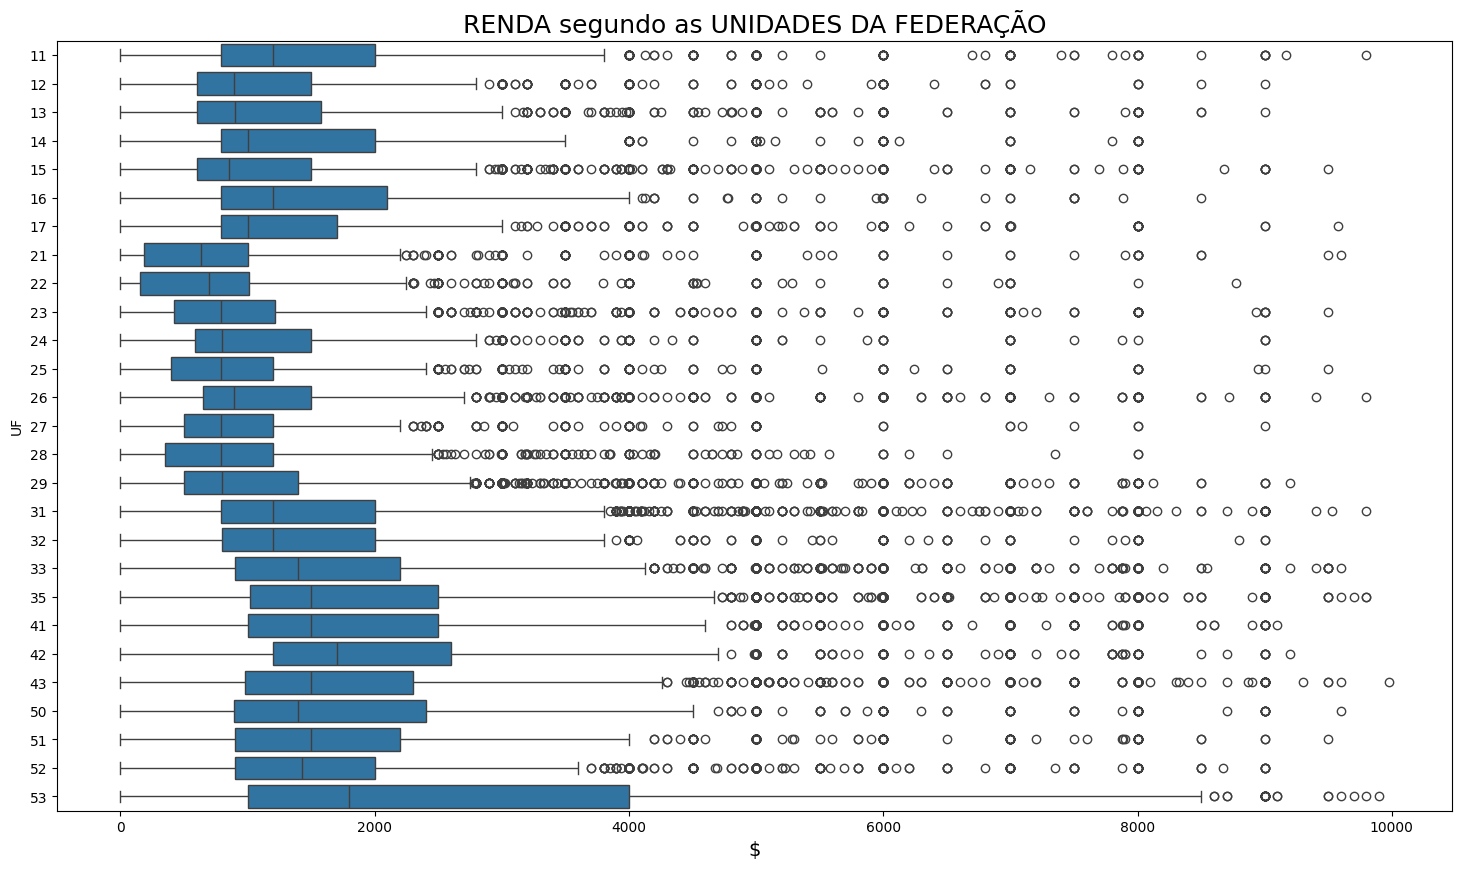

In [ ]:
ax = sns.boxplot(x = 'Renda', y = 'UF', data = dados.query('Renda < 10000'), orient='h')
ax.figure.set_size_inches(18, 10)
ax.set_title('RENDA segundo as UNIDADES DA FEDERAÇÃO', fontsize=18)
ax.set_xlabel('$', fontsize=14)

> ### Conclusões

Estados do Sul, Sudeste e o Distrito Federal (destaque para o DF, com a maior mediana e dispersão) concentram rendas mais altas, enquanto estados do Norte e, principalmente, do Nordeste (como Maranhão, Piauí, Alagoas) têm as menores medianas e caixas mais compactas. Na maior parte das UFs, há grande quantidade de outliers de renda alta, confirmando que a assimetria à direita da distribuição de renda se repete em cada estado individualmente.